In [1]:
%matplotlib notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import timeit as ti
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from itertools import combinations
from collections import Counter
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
data=pd.read_csv('./data/Restaurant/df_final_dataset.csv', index_col=[0])

In [3]:
data.columns

Index(['customer_id', 'gender', 'verified_x', 'updated_at_x',
       'location_number', 'location_type', 'latitude_x', 'longitude_x',
       'akeed_order_id', 'item_count', 'grand_total', 'payment_mode',
       'promo_code', 'vendor_discount_amount',
       'promo_code_discount_percentage', 'is_favorite', 'is_rated',
       'vendor_rating_x', 'driver_rating', 'deliverydistance',
       'preparationtime', 'vendor_id', 'created_at_x', 'LOCATION_NUMBER',
       'LOCATION_TYPE', 'CID X LOC_NUM X VENDOR', 'authentication_id',
       'latitude_y', 'longitude_y', 'vendor_category_en', 'vendor_category_id',
       'delivery_charge', 'serving_distance', 'is_open', 'prepration_time',
       'discount_percentage', 'status', 'verified_y', 'rank',
       'vendor_rating_y', 'primary_tags', 'vendor_tag_name', 'created_at_y',
       'updated_at_y'],
      dtype='object')

In [4]:
data.isnull().values.any()

False

In [5]:
data.drop(['updated_at_x', 'latitude_x', 'longitude_x',
        'driver_rating','preparationtime', 'created_at_x', 'LOCATION_NUMBER',
       'LOCATION_TYPE', 'CID X LOC_NUM X VENDOR', 'authentication_id',
       'latitude_y', 'longitude_y', 'vendor_category_en', 'vendor_category_id',
       'delivery_charge', 'status', 'verified_y',
       'vendor_rating_y', 'primary_tags','updated_at_y'],axis=1,inplace=True)

Finding the correlation betweeen the variables in the dataset for further analysis

<IPython.core.display.Javascript object>


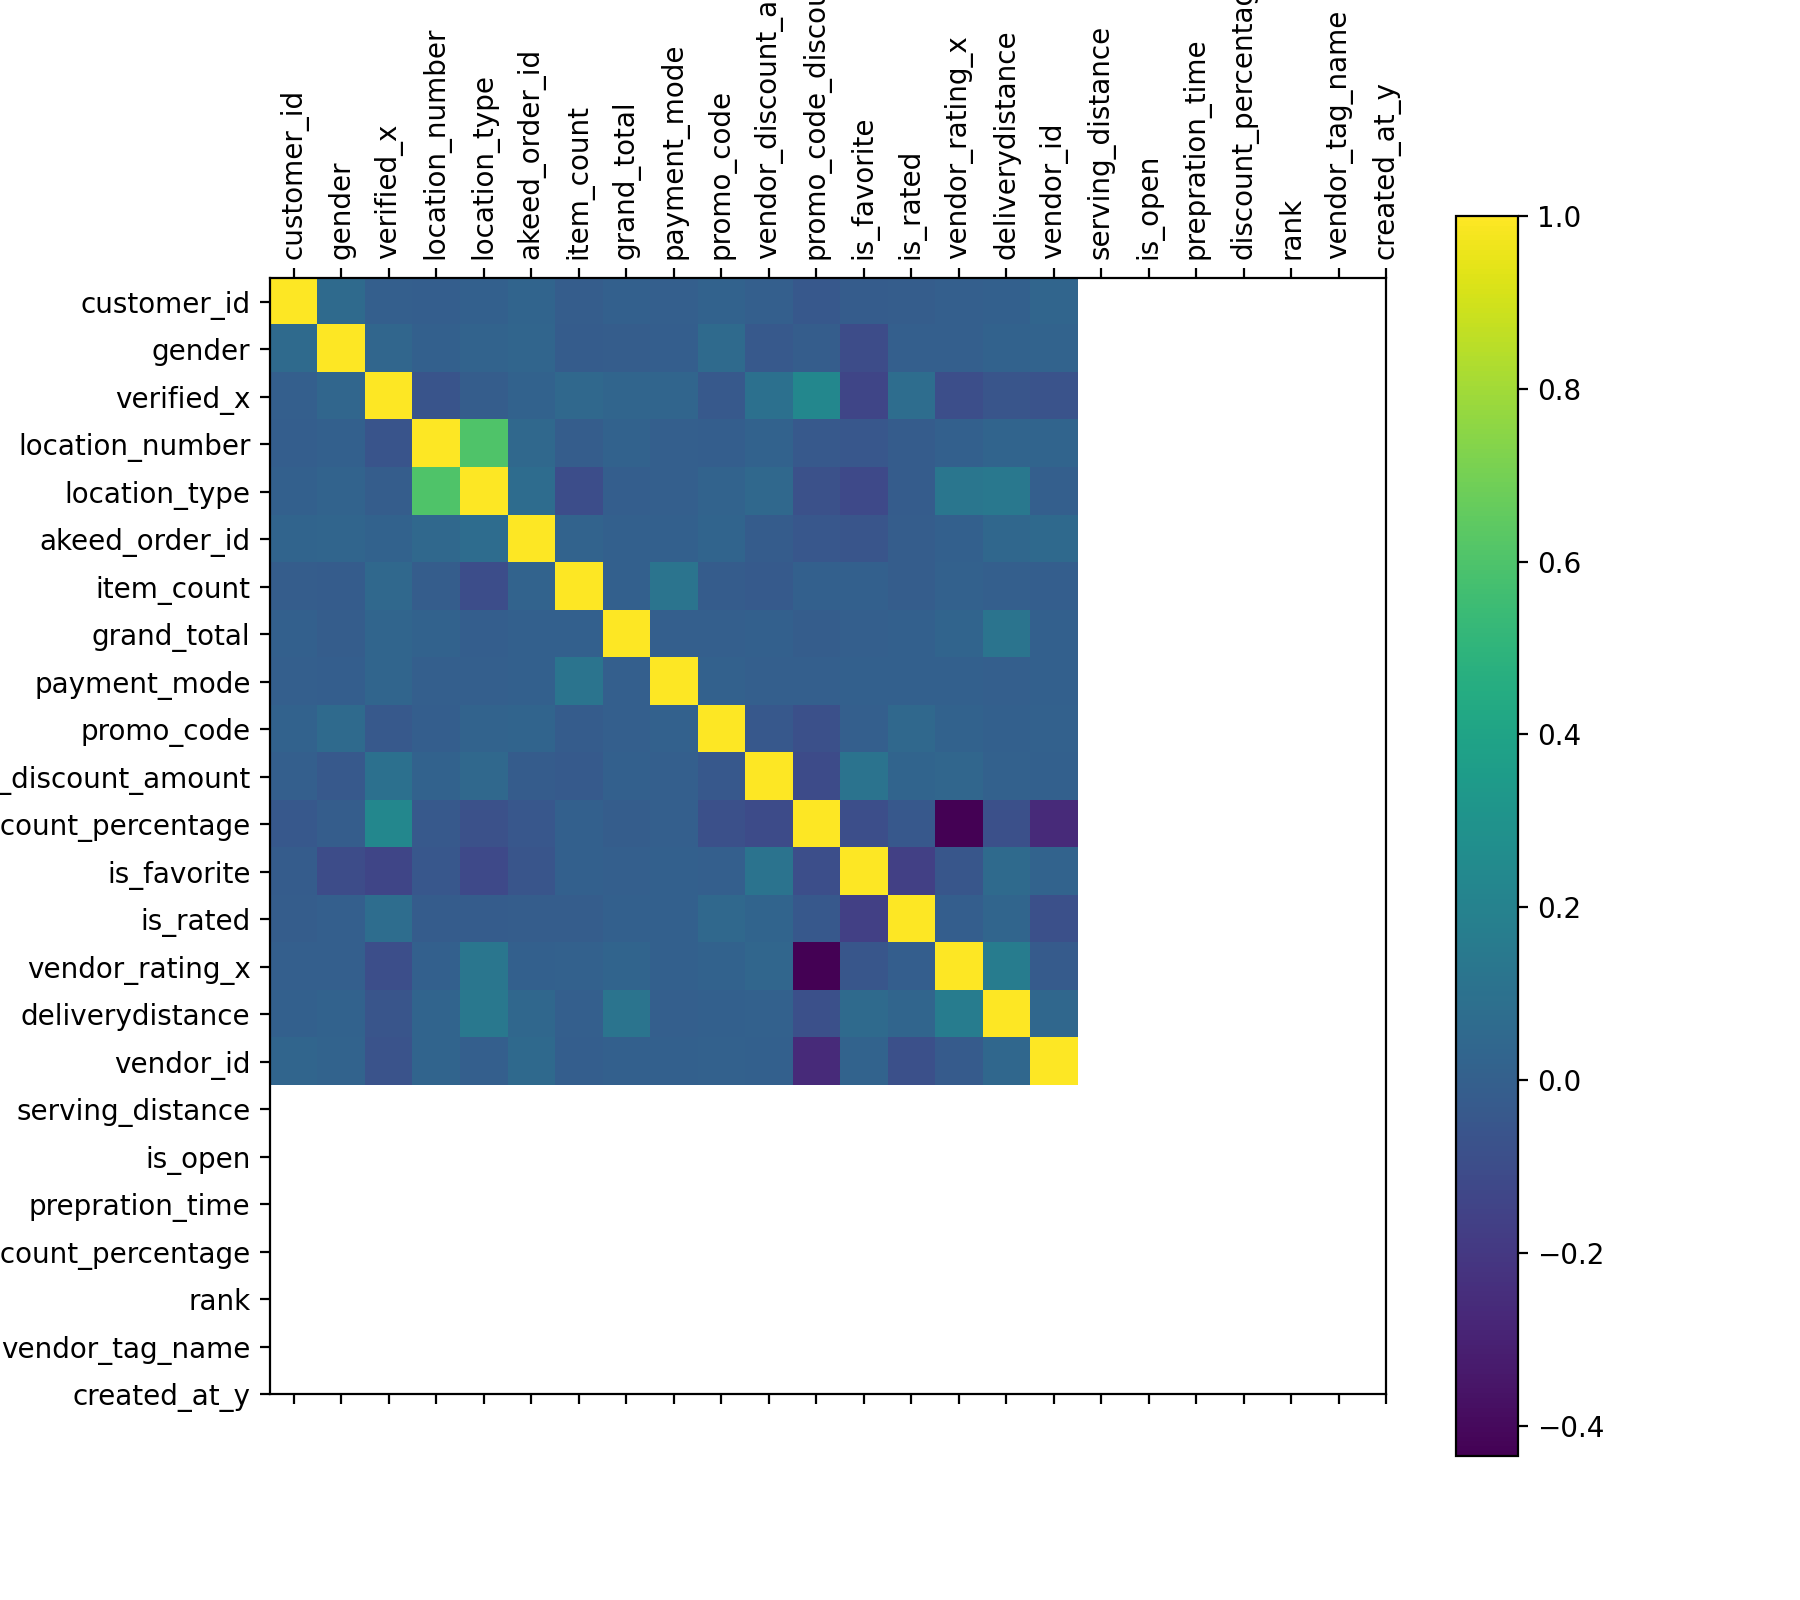

In [6]:
f = plt.figure(figsize=(9, 8))
plt.matshow(data.corr(), fignum=f.number)
plt.xticks (range (len (data.columns)), data.columns, rotation='vertical') 
plt.yticks(range (len (data.columns)), data.columns) 
plt.colorbar()
plt.show ()

Do Customers only order from well known restaurants?

<IPython.core.display.Javascript object>


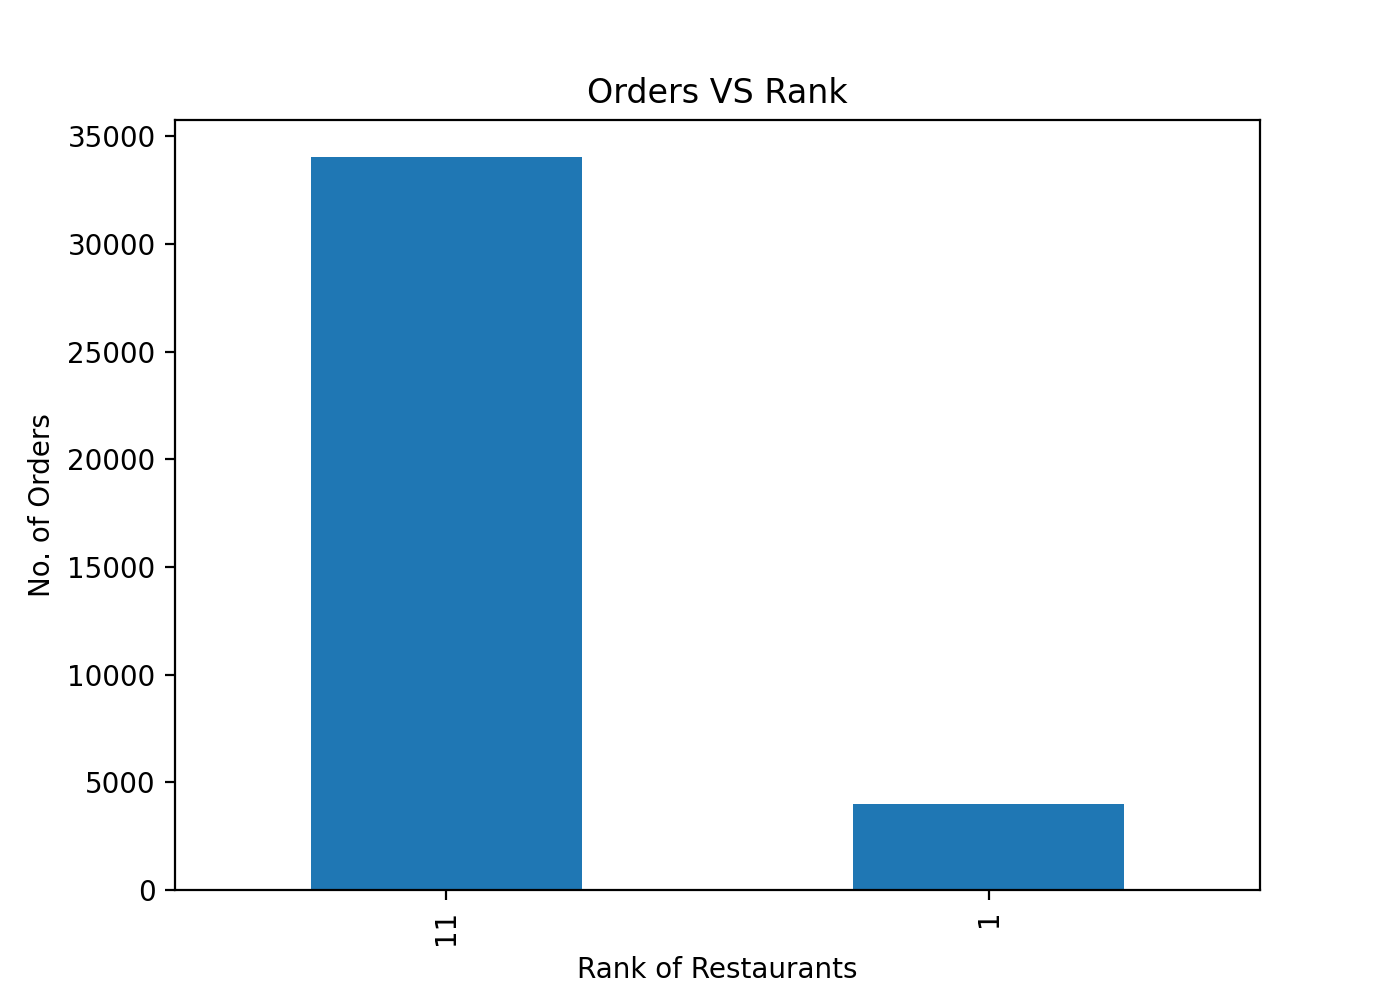

In [7]:
#data['rank'].value_counts()
plt.figure(figsize = (7,5))
ax = data['rank'].value_counts().plot(kind='bar')
plt.xlabel('Rank of Restaurants')
plt.ylabel('No. of Orders')
plt.title('Orders VS Rank')
plt.show()

What is the most preferred payment modes by customers?

In [8]:
c=data['payment_mode']
l=[]
for i in range(len(c)):
    l.append(c.values[i])

<IPython.core.display.Javascript object>


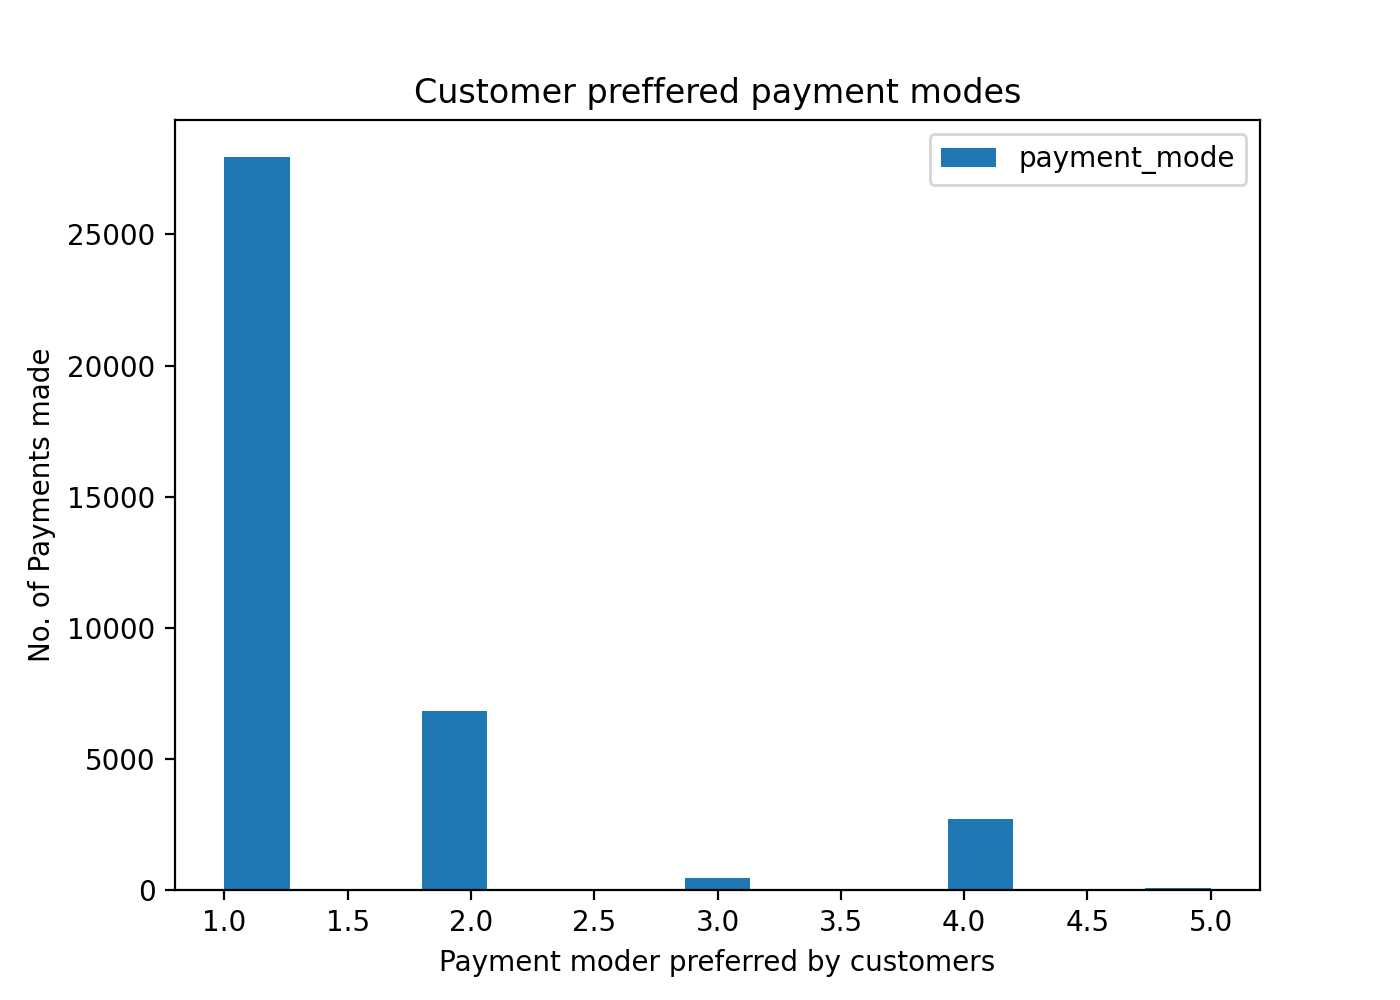

In [9]:
df1=pd.DataFrame(l)
df1.columns=['payment_mode']
df1.plot(kind='hist', bins=15,figsize=(7,5))
plt.xlabel('Payment moder preferred by customers')
plt.ylabel('No. of Payments made')
plt.title('Customer preffered payment modes')
plt.show()

Do customers always order from their favorite restaurants

<IPython.core.display.Javascript object>


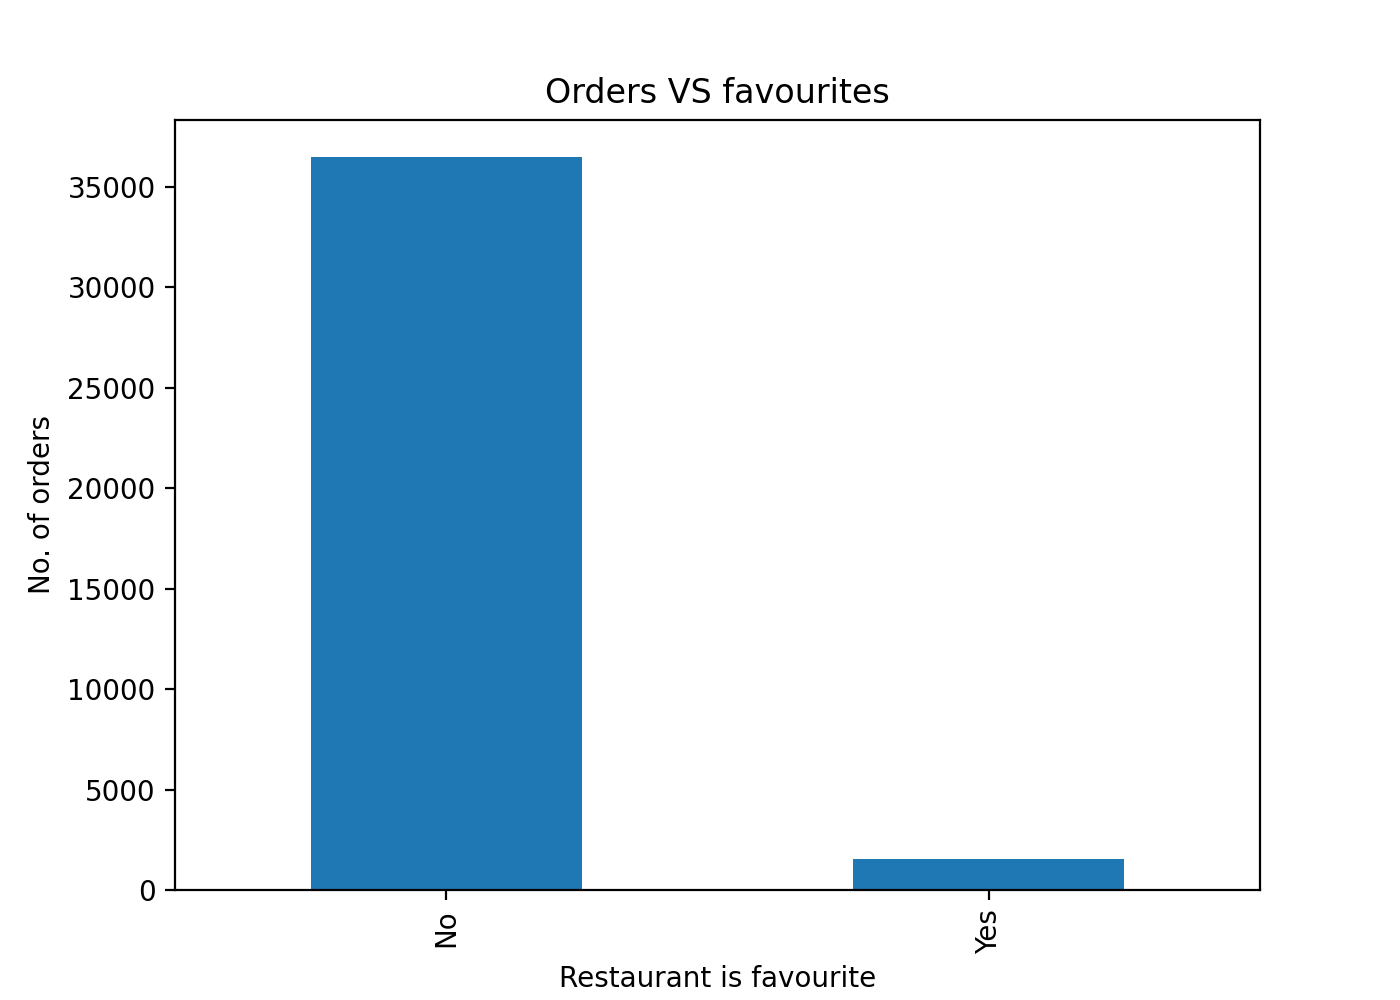

In [10]:
#data.is_favorite.value_counts()
plt.figure(figsize = (7,5))
ax = data.is_favorite.value_counts().plot(kind='bar')
plt.xlabel('Restaurant is favourite')
plt.ylabel('No. of orders')
plt.title('Orders VS favourites')
plt.show()

Do customers only order if offered a promo code?

<IPython.core.display.Javascript object>


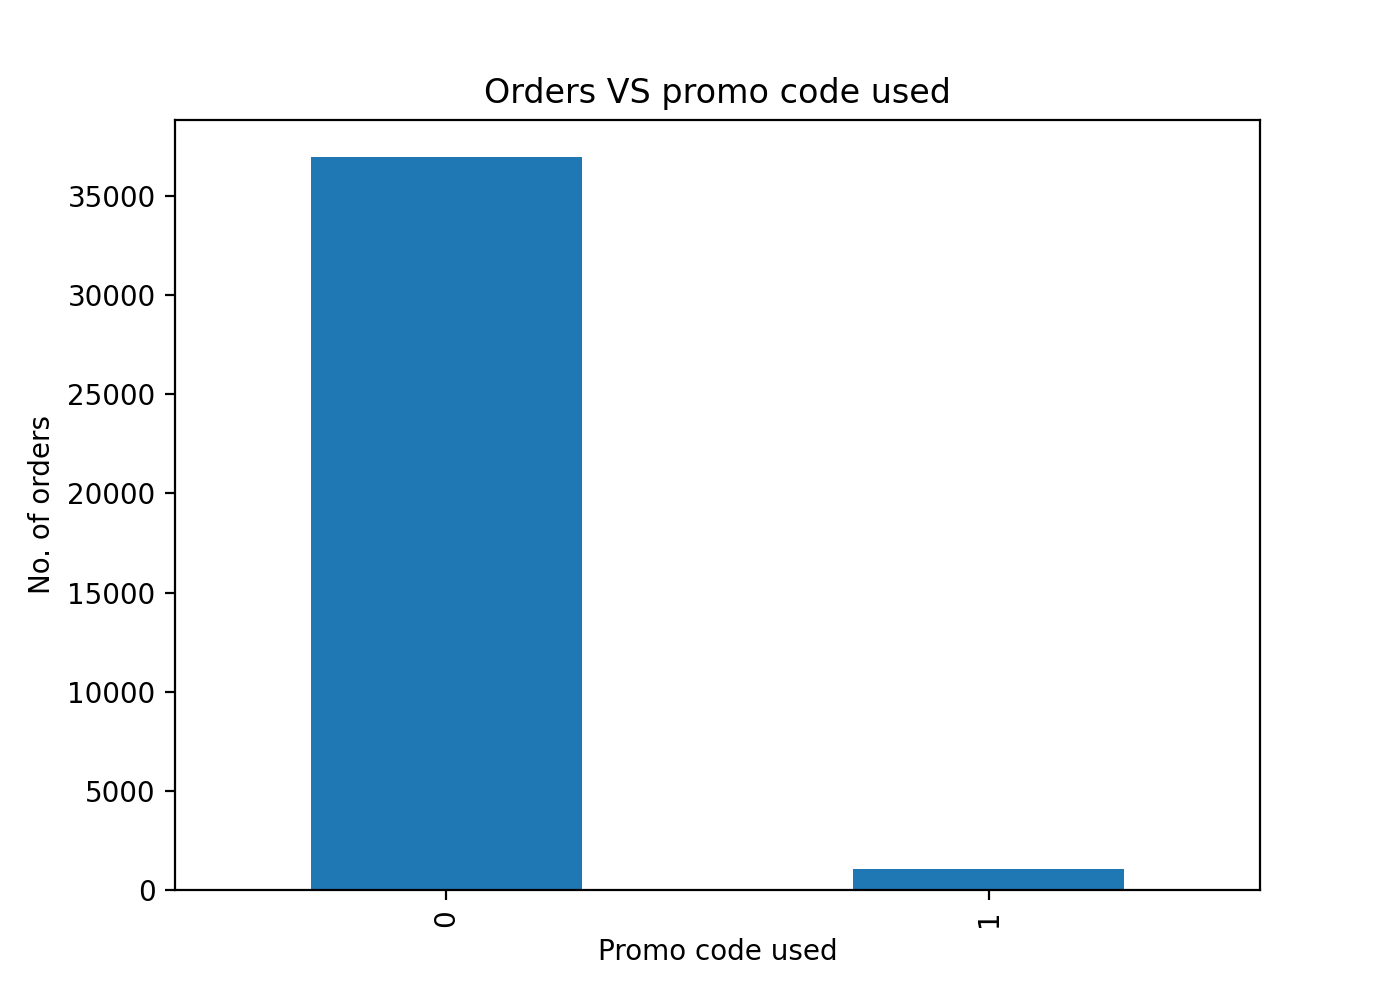

In [11]:
#data.promo_code.value_counts()
plt.figure(figsize=(7,5))
ax = data.promo_code.value_counts().plot(kind='bar')
plt.xlabel('Promo code used')
plt.ylabel('No. of orders')
plt.title('Orders VS promo code used')
plt.show()

Which restaurant category is the most popular

Which are the top five restaurant categories customers tend to order the most?!

In [12]:
x=data.vendor_tag_name
w=[]
for i in range(len(x)):
    w.append(x[i][0:])
w=pd.DataFrame(w)
w.columns=['Categories']
p=w.value_counts()

In [13]:
p=w.value_counts()
df=pd.DataFrame(p)
df=p.reset_index()
df.columns=['Categories','count_o']
df=df.sort_values(by='count_o', ascending=False).head(5)
df=df.set_index('Categories')

<IPython.core.display.Javascript object>


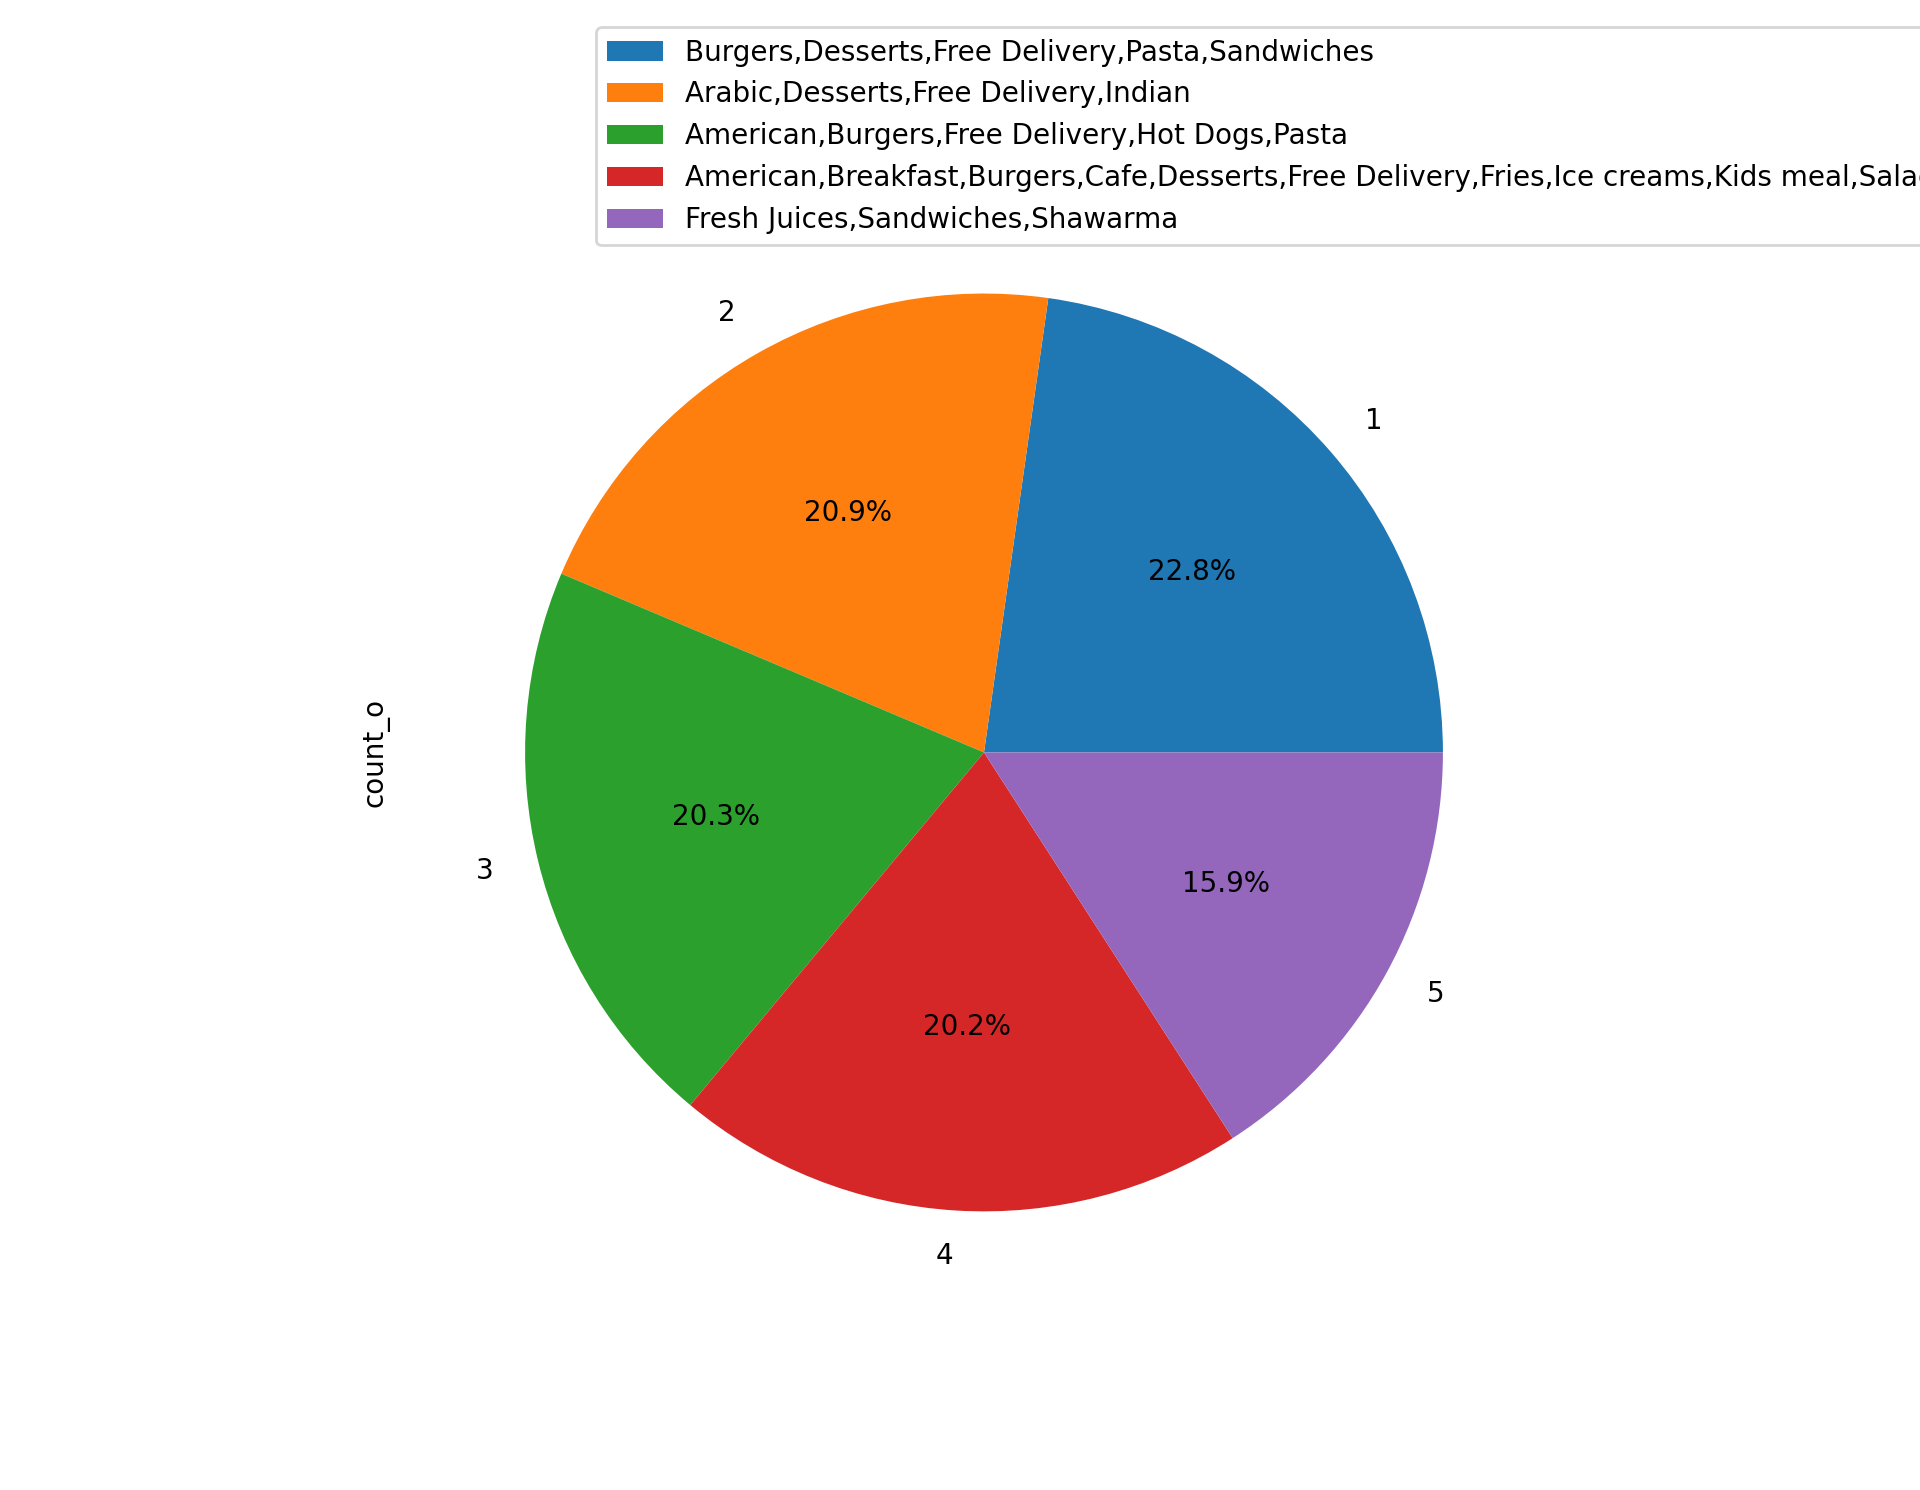

In [14]:
y=df.index.unique()
plt.rcParams["figure.figsize"] = [9.60, 7.45]
ax = df.plot.pie(y='count_o',autopct='%1.1f%%', labels = ['1','2','3','4','5'])
plt.legend(bbox_to_anchor=(0.15, 0.93), labels= y )


Does the time taken for preparation affect the ratings?

In [15]:
data.prepration_time.mean()


4.3912483235595765

<IPython.core.display.Javascript object>


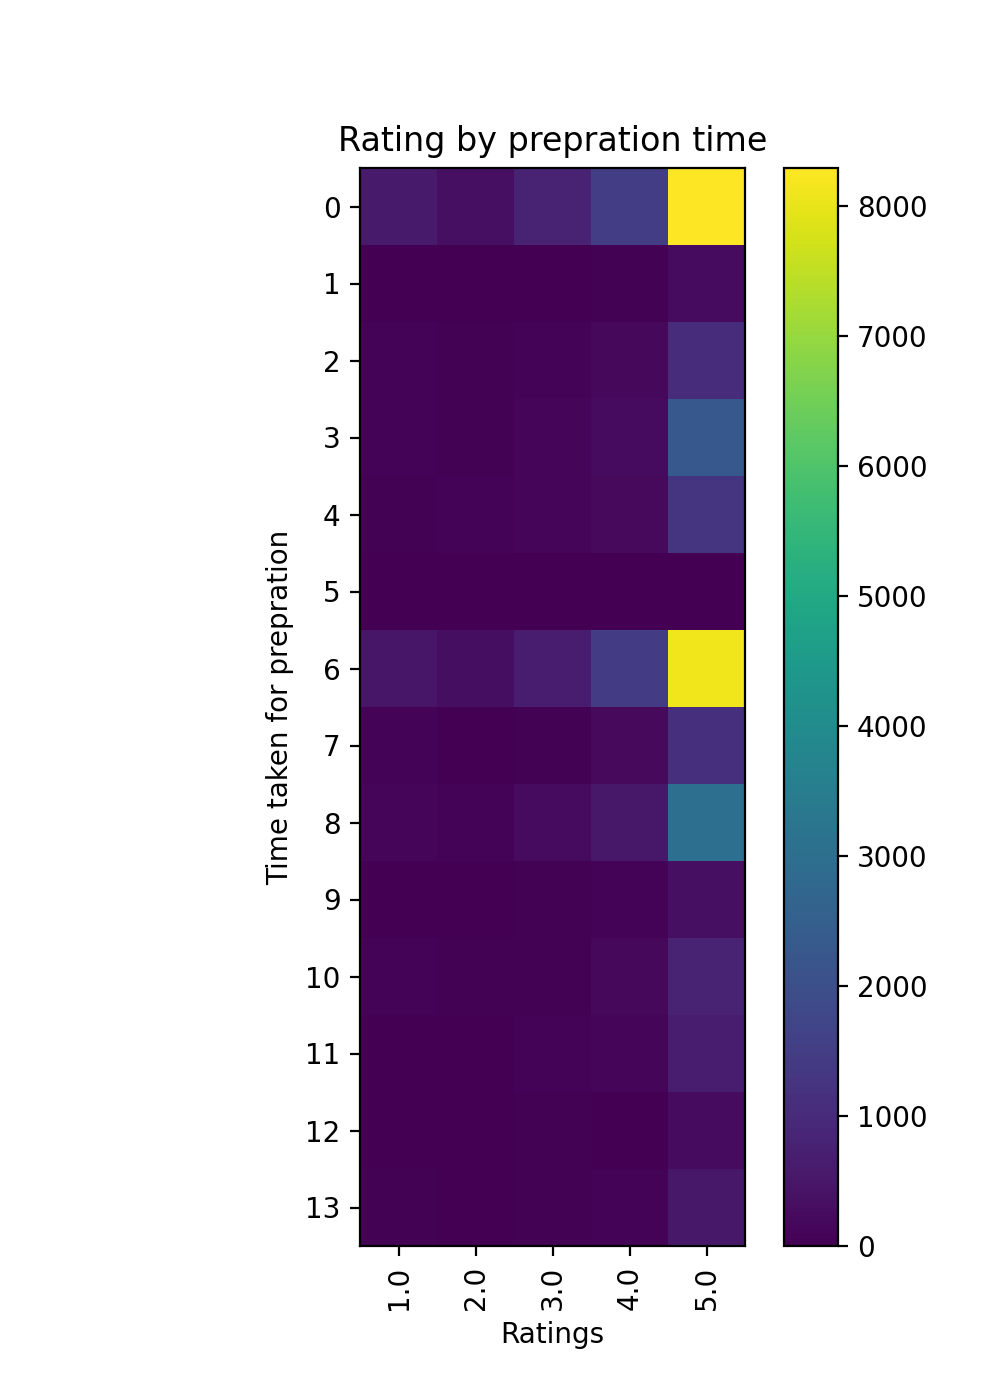

In [16]:
v=pd.crosstab(data.prepration_time,data.vendor_rating_x)
img=v.to_numpy()
fig = plt.figure(figsize=(5,7))
axis = fig.add_subplot(111)
img = axis.imshow(img)
fig.colorbar(img)
col_labels = v.columns.to_list()
row_labels = v.index.values
axis.set_xticks(range(len(col_labels)))
axis.set_yticks(range(len(row_labels)))
axis.set_xticklabels(col_labels, rotation='vertical')
axis.set_yticklabels(row_labels)
plt.xlabel('Ratings')
plt.ylabel('Time taken for prepration')
plt.title('Rating by prepration time')
plt.show()

From which location are the maximum orders placed?

Which location do customers usually order from?

<IPython.core.display.Javascript object>


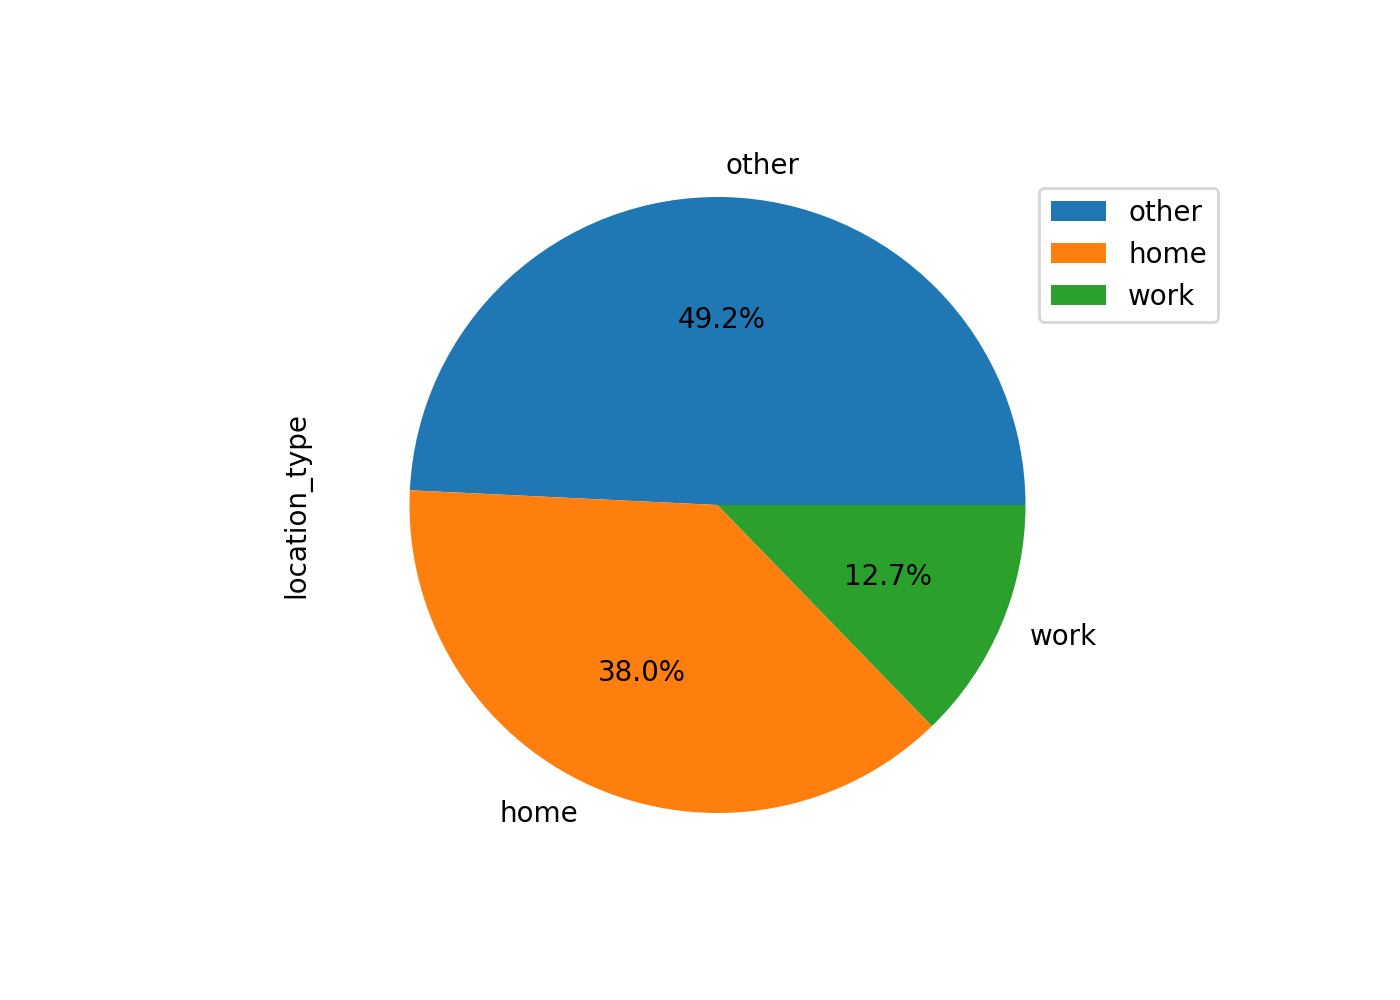

In [17]:
plt.figure(figsize = (7,5))
ax = data.location_type.value_counts().plot(kind = 'pie',autopct='%1.1f%%', legend=True)
plt.legend(bbox_to_anchor=(0.90, 0.93))

What is the peak time of the day at the restaurants?

In [18]:
data['odr_time'] = pd.to_datetime(data['created_at_y'])
data['odr_time']= data['odr_time'].dt.hour


<IPython.core.display.Javascript object>


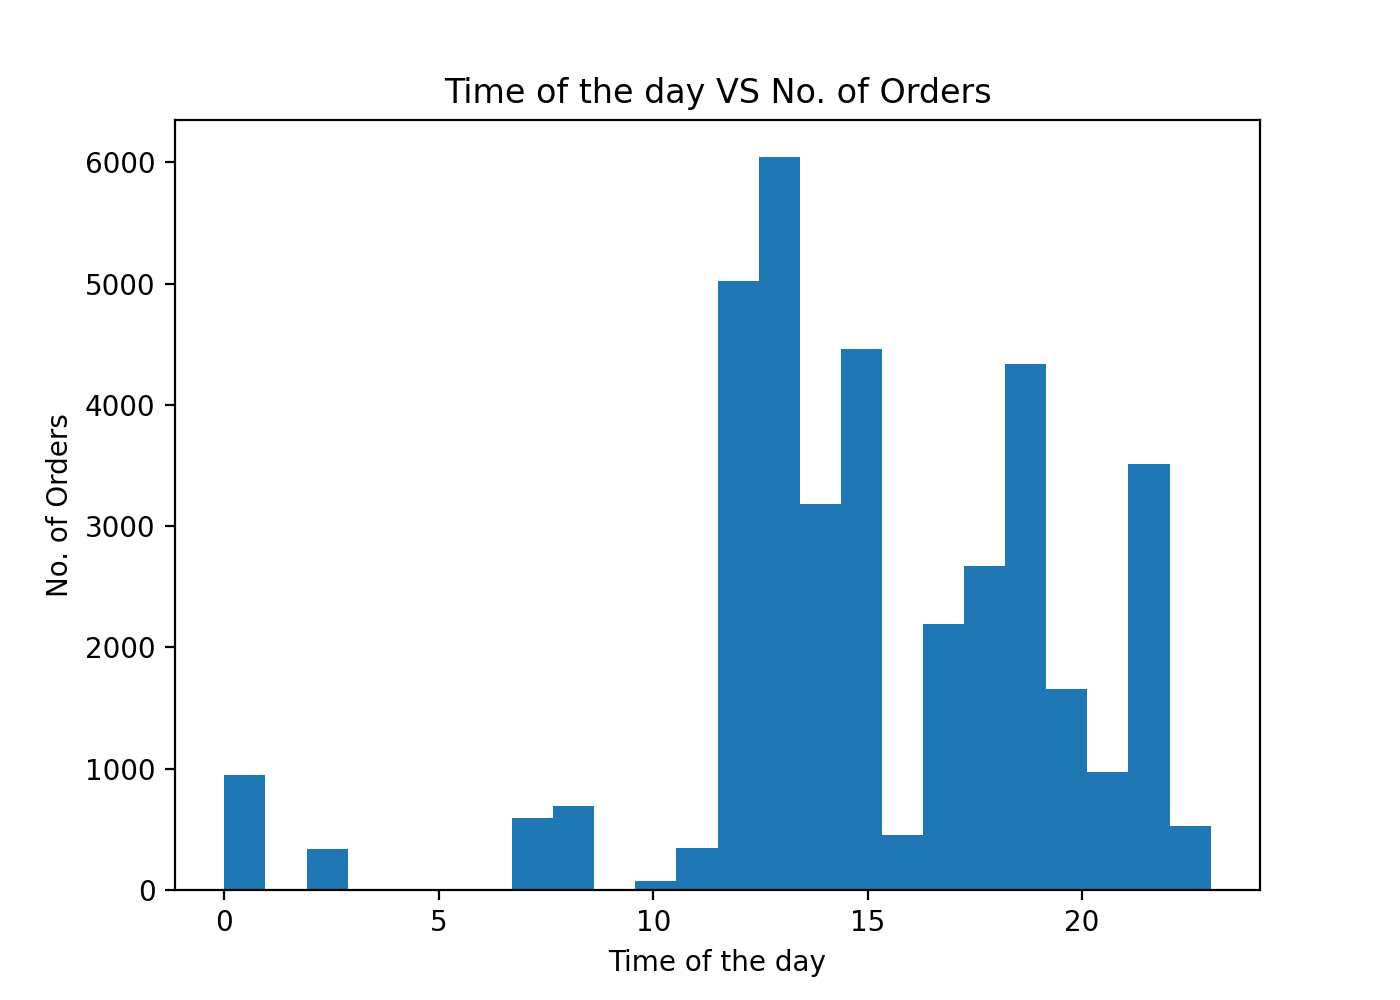

In [19]:
plt.figure(figsize = (7,5))
ax = data['odr_time'].plot(kind = 'hist', bins=24)
plt.xlabel('Time of the day')
plt.ylabel('No. of Orders')
plt.title('Time of the day VS No. of Orders')
plt.show()

Does the distance of the restaurant matter to customers?

<IPython.core.display.Javascript object>


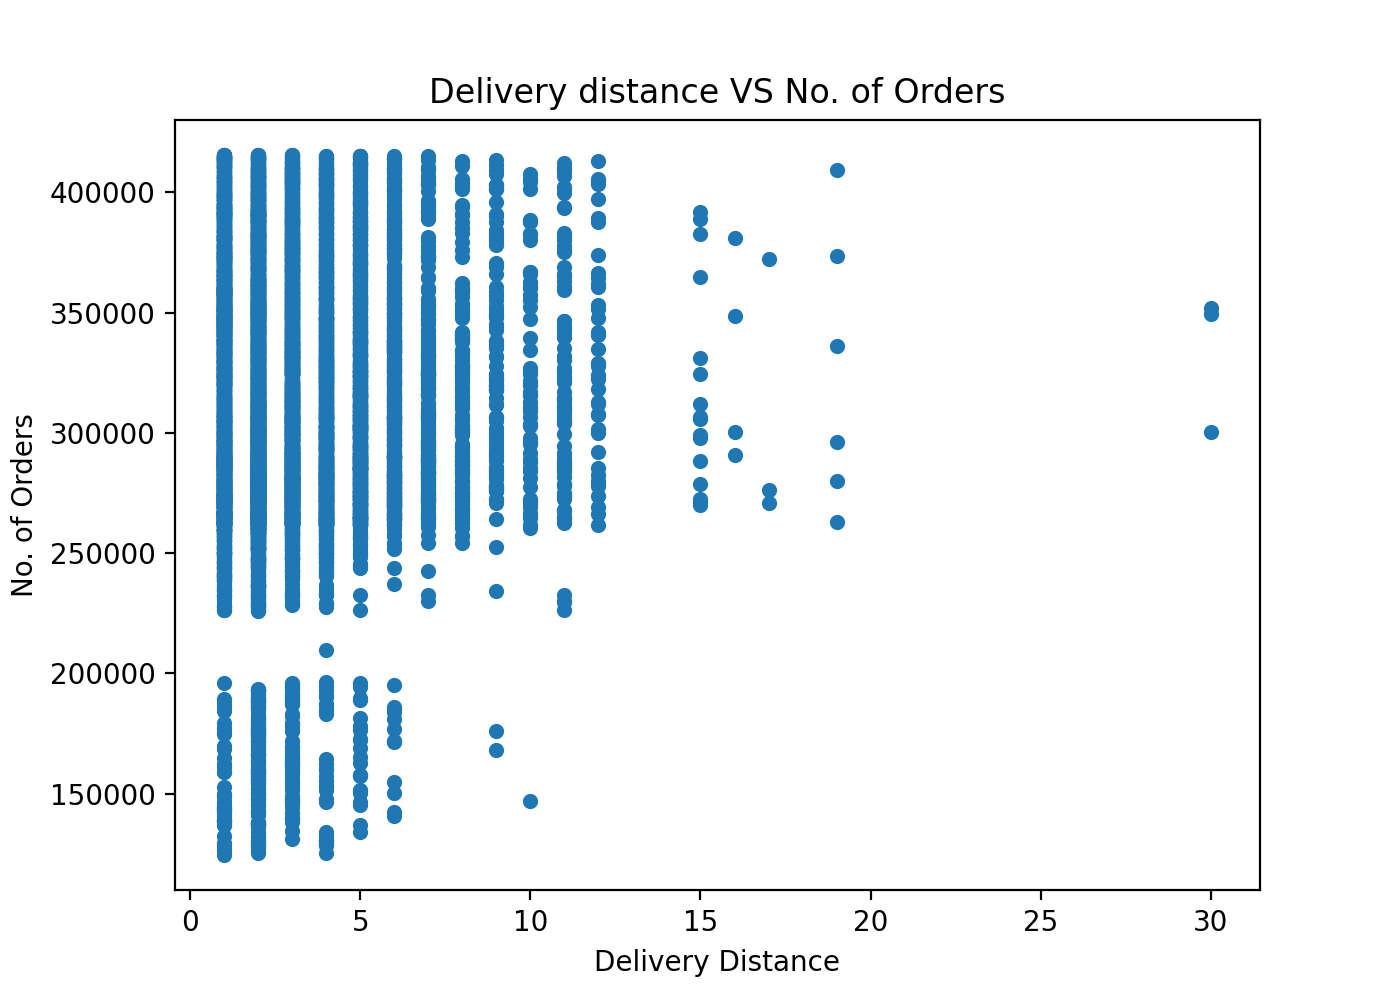

In [21]:
d=data.groupby('akeed_order_id').count()['deliverydistance']
d=d.reset_index()
d.plot.scatter(x='deliverydistance', y='akeed_order_id',figsize=(7, 5))
plt.xlabel('Delivery Distance')
plt.ylabel('No. of Orders')
plt.title('Delivery distance VS No. of Orders')
plt.show()

Plotting the distribution of orders placed by respective gender by the location type

Are there any specific preferences of the customers according to their gender?

In [22]:
c=pd.crosstab(data.gender,data.location_type)

<IPython.core.display.Javascript object>


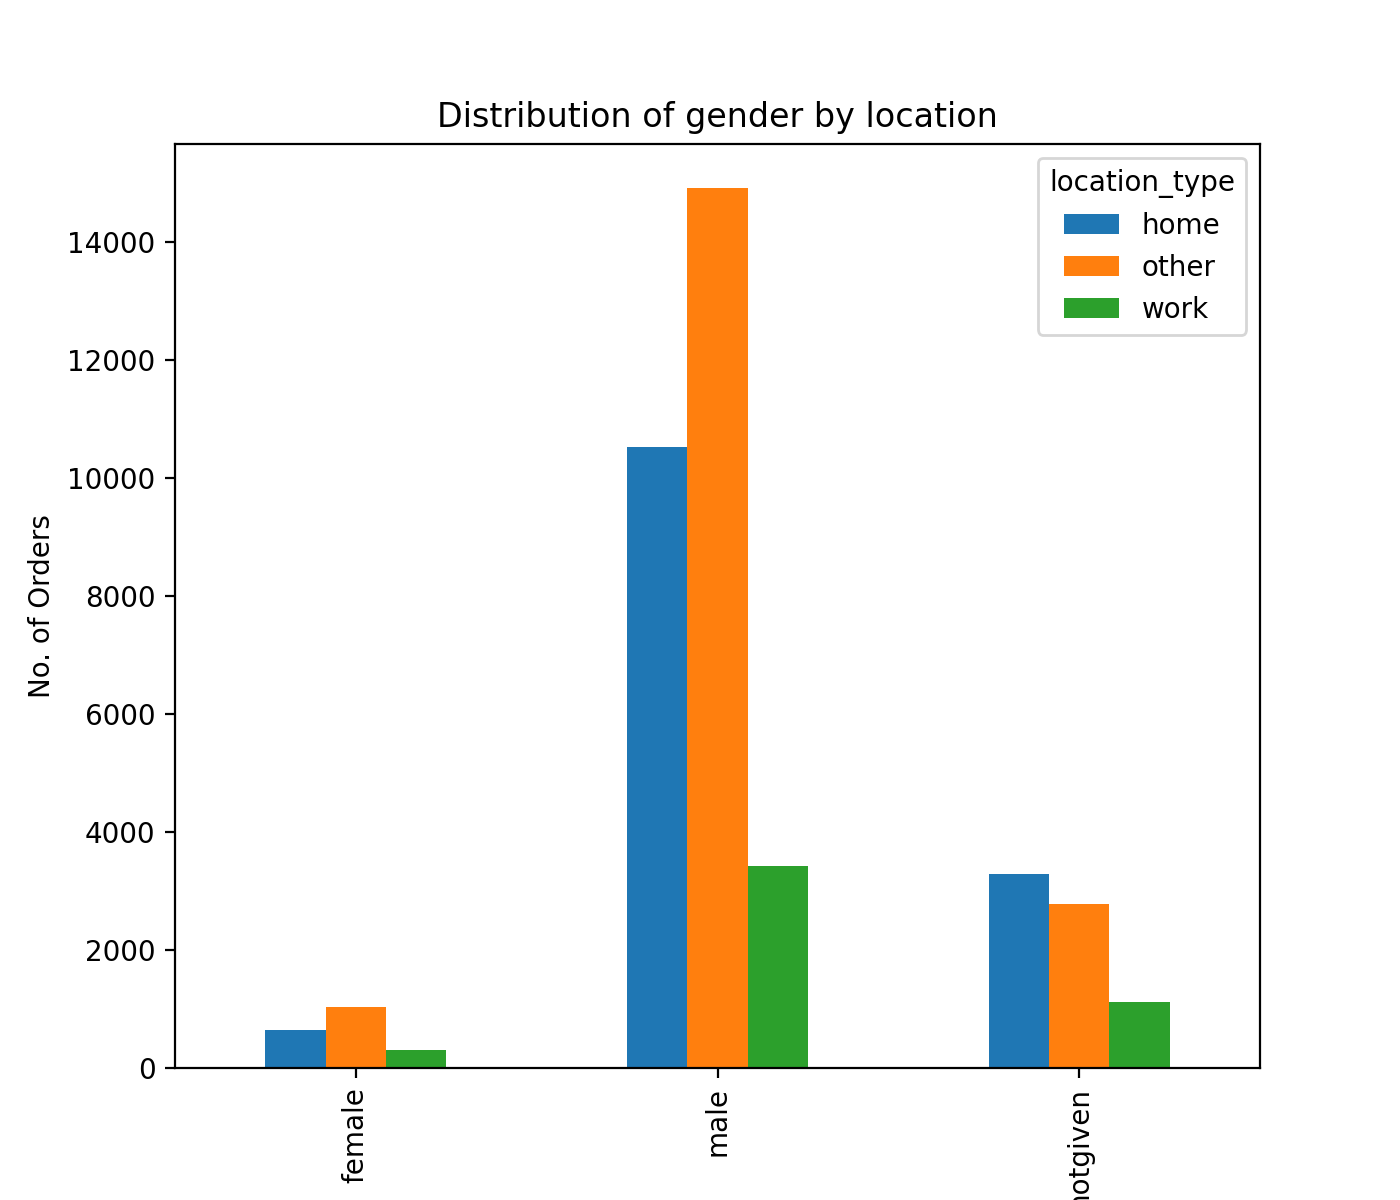

In [23]:
fig = plt.figure(figsize=(7,6))
axis = fig.add_subplot(111)
c.plot.bar(ax=axis)
plt.xlabel('Distribution of  orders placed by gender and location')
plt.ylabel('No. of Orders')
plt.title('Distribution of gender by location')
plt.show()

Distribution of the restaurants based on location.

In [24]:
a=data.groupby('location_number').count()['vendor_id']
a=a.reset_index()


<IPython.core.display.Javascript object>


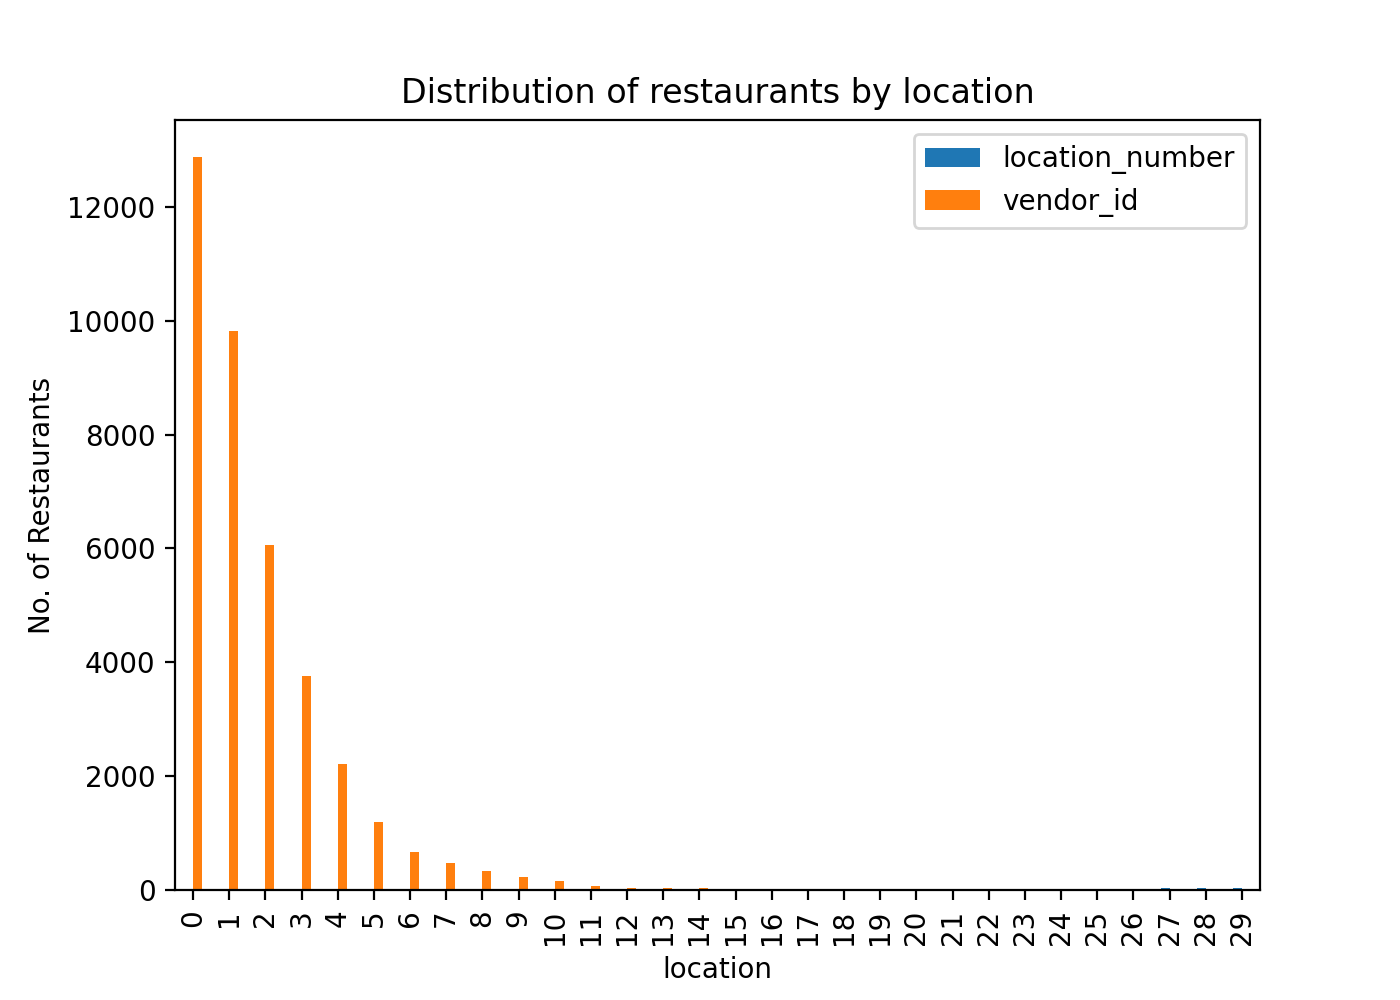

In [25]:
fig = plt.figure(figsize=(7,5))
axis = fig.add_subplot(111)
a.plot.bar(ax=axis)
plt.xlabel('location')
plt.ylabel('No. of Restaurants')
plt.title('Distribution of restaurants by location')
plt.show()

Do customers prefer to order from restaurants which provide a discount?

<IPython.core.display.Javascript object>


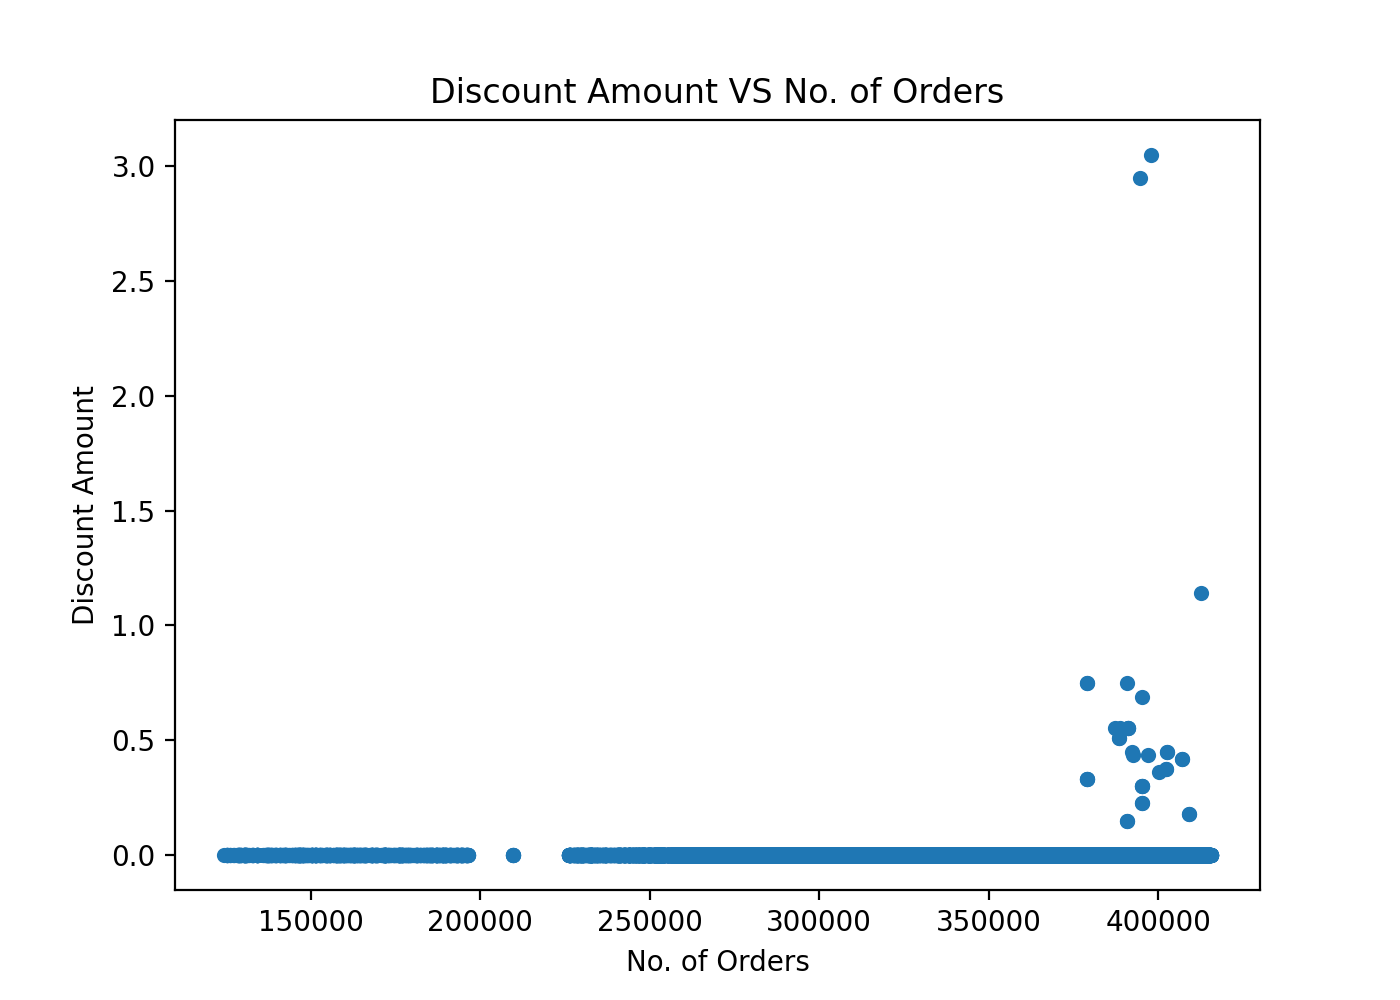

In [26]:
data.plot.scatter(x='akeed_order_id', y='vendor_discount_amount', figsize=(7, 5))
plt.xlabel('No. of Orders')
plt.ylabel('Discount Amount')
plt.title('Discount Amount VS No. of Orders')
plt.show()

In [27]:
e=data.groupby('customer_id').count()['akeed_order_id']
e=e.reset_index()
e.columns=['Cust_id','No_of_orders_placed']
print(e)

      Cust_id  No_of_orders_placed
0     00HWUU3                    2
1     00OT8JX                   80
2     018GT0H                    3
3     01BY7WQ                    4
4     01HG648                    2
...       ...                  ...
4993  ZZ66LJK                    8
4994  ZZ9EINR                    2
4995  ZZG19GH                   12
4996  ZZJSJYC                   17
4997  ZZY3N0D                    8

[4998 rows x 2 columns]


In [28]:
f=data.groupby('customer_id').sum()['grand_total']
f=f.reset_index()
f.columns=['Cust_id','Total_amount_spent']
print(f)

      Cust_id  Total_amount_spent
0     00HWUU3                12.0
1     00OT8JX              3096.5
2     018GT0H                50.1
3     01BY7WQ                57.2
4     01HG648                15.2
...       ...                 ...
4993  ZZ66LJK                82.0
4994  ZZ9EINR                22.5
4995  ZZG19GH               124.0
4996  ZZJSJYC               589.5
4997  ZZY3N0D                54.0

[4998 rows x 2 columns]


In [29]:
df=pd.merge(e,f,on='Cust_id',how='inner')
df

,Cust_id,No_of_orders_placed,Total_amount_spent
0,00HWUU3,2,12.0
1,00OT8JX,80,3096.5
2,018GT0H,3,50.1
3,01BY7WQ,4,57.2
4,01HG648,2,15.2
...,...,...,...
4993,ZZ66LJK,8,82.0
4994,ZZ9EINR,2,22.5
4995,ZZG19GH,12,124.0
4996,ZZJSJYC,17,589.5


In [30]:
Q1=df.No_of_orders_placed.quantile(0.05)
Q3=df.No_of_orders_placed.quantile(0.95)
IQR=Q3-Q1
df=df[(df.No_of_orders_placed>=Q1-1.5*IQR) & (df.No_of_orders_placed<=Q3+1.5*IQR)]

Q1=df.Total_amount_spent.quantile(0.05)
Q3=df.Total_amount_spent.quantile(0.95)
IQR=Q3-Q1
df=df[(df.Total_amount_spent>=Q1-1.5*IQR) & (df.Total_amount_spent<=Q3+1.5*IQR)]
df.shape

(4898, 3)

In [31]:
B= df[['No_of_orders_placed','Total_amount_spent']]
scaler=MinMaxScaler()
df_s=scaler.fit_transform(B)

In [32]:
df_s=pd.DataFrame(df_s)
df_s.columns=('No_of_orders_placed','Total_Amount_spent')
df_s.head(5)

,No_of_orders_placed,Total_Amount_spent
0,0.015385,0.012376
1,0.030769,0.051671
2,0.046154,0.058993
3,0.015385,0.015677
4,0.046154,0.109323


In [33]:
kmeans=KMeans(n_clusters=3, max_iter=100)
kmeans.fit(df_s)
p=kmeans.labels_
print(kmeans.labels_)

[0 0 0 ... 2 2 0]


In [34]:
df['Cluster_Id']=p
df

,Cust_id,No_of_orders_placed,Total_amount_spent,Cluster_Id
0,00HWUU3,2,12.0,0
2,018GT0H,3,50.1,0
3,01BY7WQ,4,57.2,0
4,01HG648,2,15.2,0
5,01RMLT7,4,106.0,0
...,...,...,...,...
4993,ZZ66LJK,8,82.0,0
4994,ZZ9EINR,2,22.5,0
4995,ZZG19GH,12,124.0,2
4996,ZZJSJYC,17,589.5,2


Clustering of customers based on the total amount spent on food.

<IPython.core.display.Javascript object>


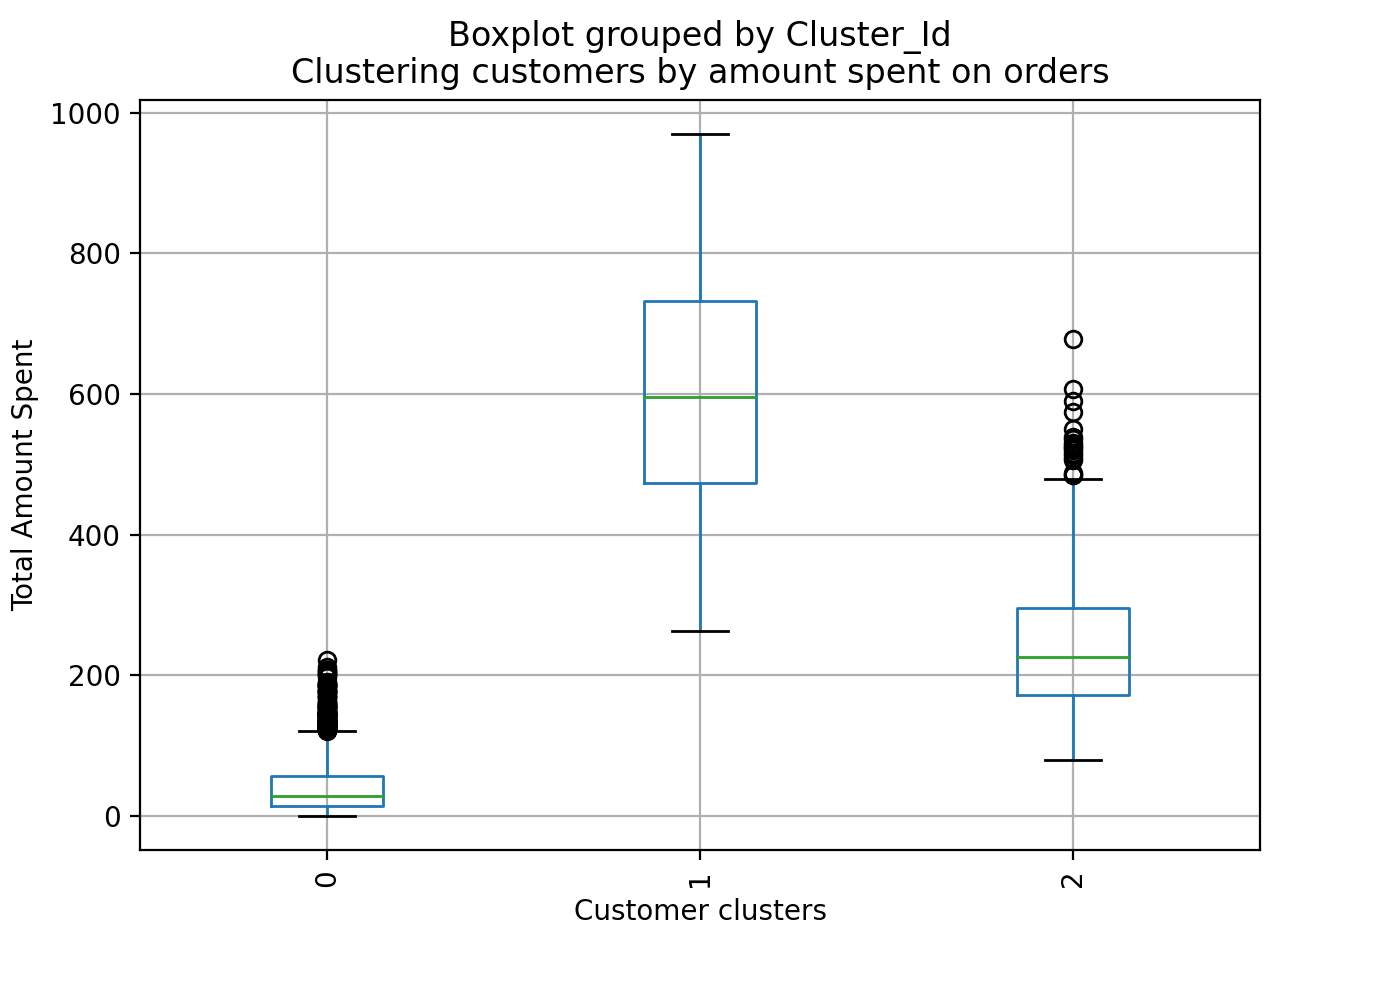

In [35]:
fig = plt.figure(figsize=(7,5))
axis = fig.add_subplot(111)
df.boxplot(column='Total_amount_spent', by='Cluster_Id', rot=90, ax = axis)
plt.xlabel('Customer clusters')
plt.ylabel('Total Amount Spent')
plt.title('Clustering customers by amount spent on orders')
plt.show()

Clustering of customers based on the frequency of orders placed at restaurants.

<IPython.core.display.Javascript object>


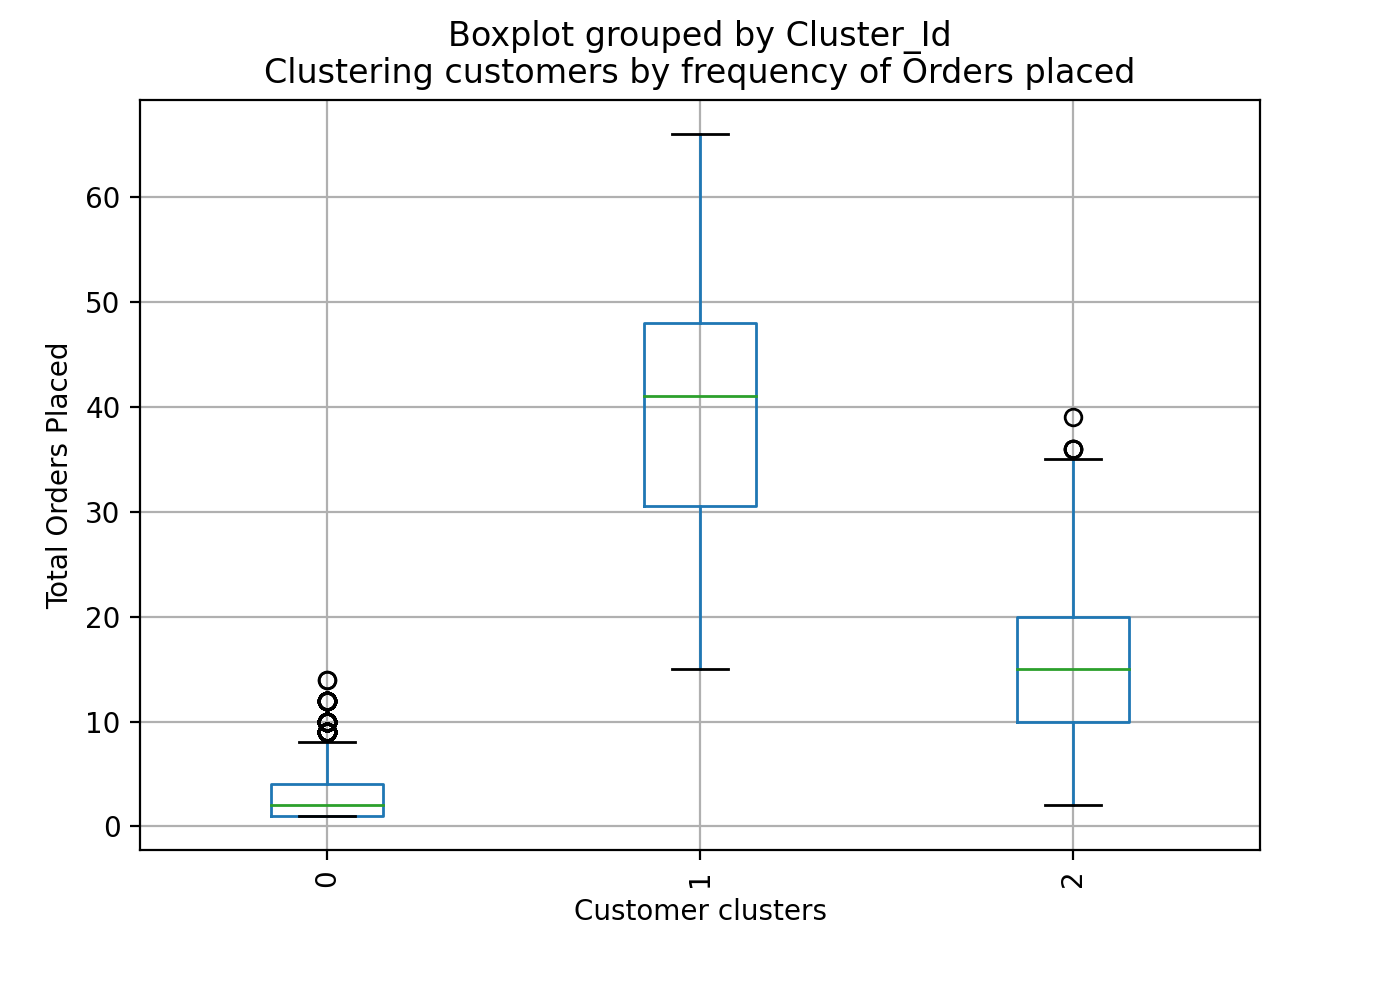

In [36]:
fig = plt.figure(figsize=(7,5))
axis = fig.add_subplot(111)
df.boxplot(column='No_of_orders_placed', by='Cluster_Id', rot=90, ax = axis)
plt.xlabel('Customer clusters')
plt.ylabel('Total Orders Placed')
plt.title('Clustering customers by frequency of Orders placed')
plt.show()


CDF and PDF of the serving distance covered by the vendors.

In [37]:
dist = data.groupby(by='customer_id').count()['serving_distance']
dist =dist.sort_values(ascending=False)

<IPython.core.display.Javascript object>


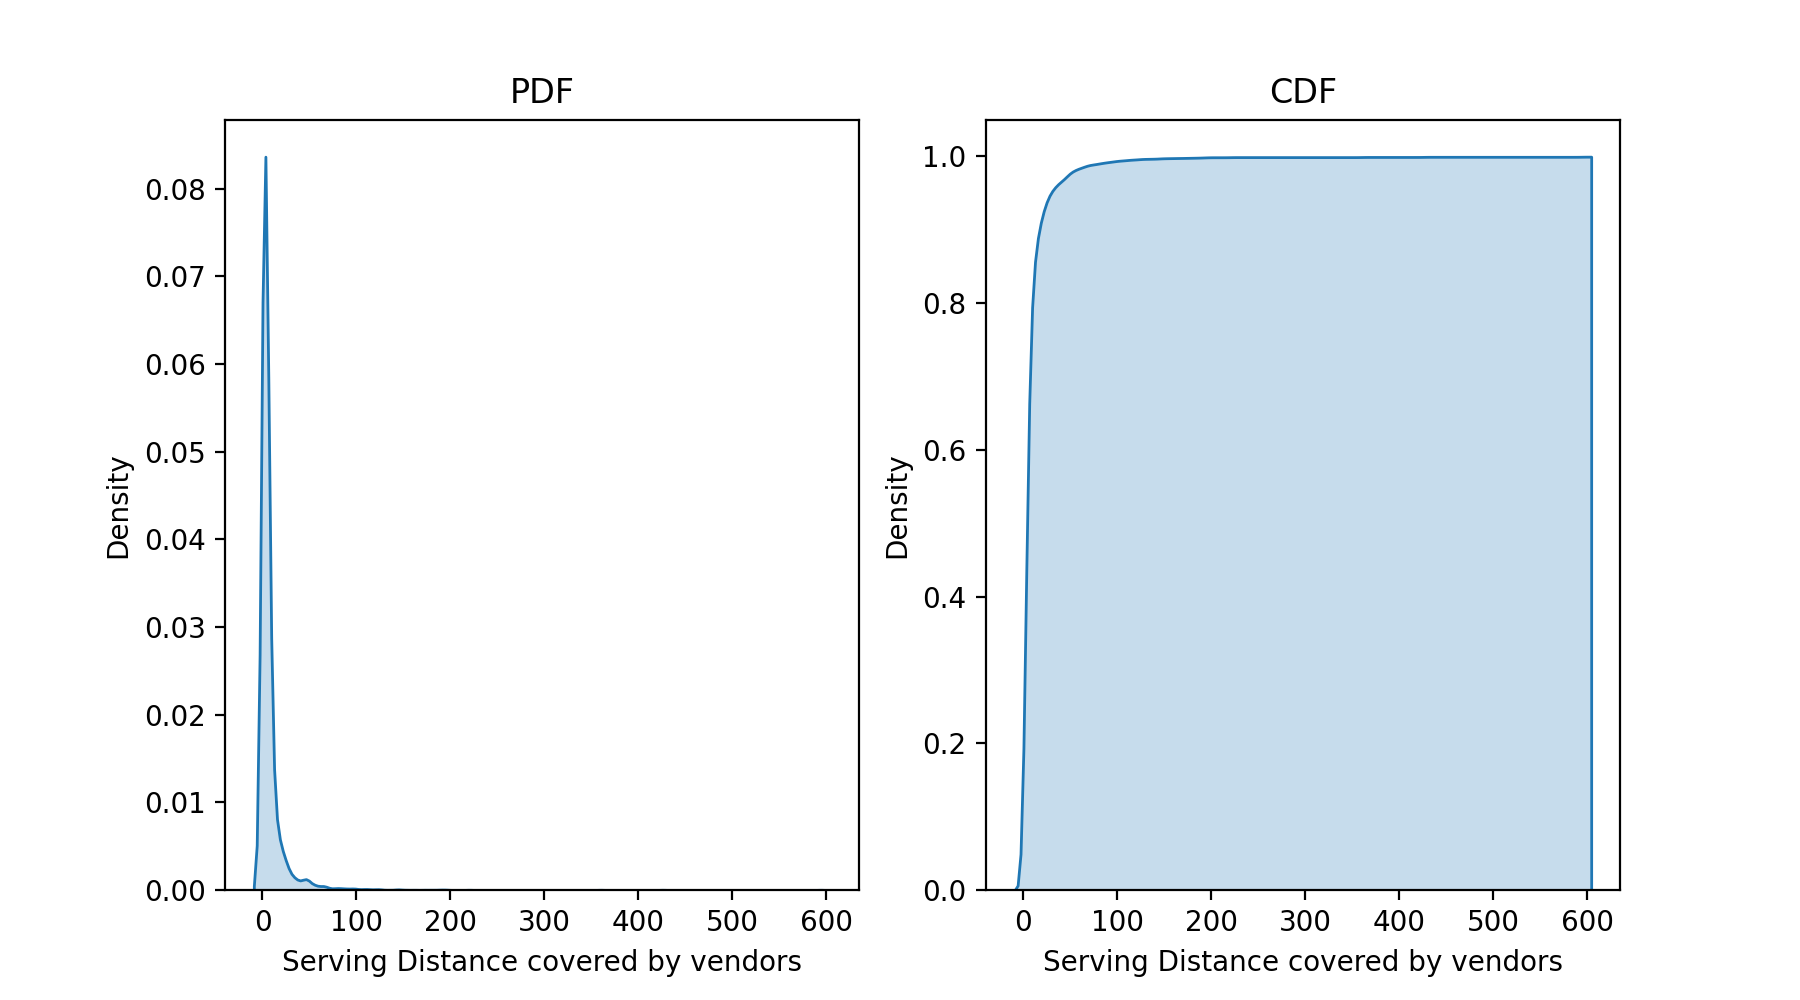

In [38]:
fig = plt.figure(figsize=(9,5))
ax1 = plt.subplot(121)
sns.kdeplot(dist, shade=True, ax=ax1)
plt.xlabel('Serving Distance covered by vendors')
plt.title("PDF")
ax2 = plt.subplot(122)
sns.kdeplot(dist, shade=True, cumulative=True,ax=ax2)
plt.xlabel('Serving Distance covered by vendors')
plt.title('CDF')
plt.show()

CDF and PDF of the open hours of the restaurant.

In [40]:
dist = data.groupby(by='vendor_id').count()['is_open']
dist =dist.sort_values(ascending=False)

<IPython.core.display.Javascript object>


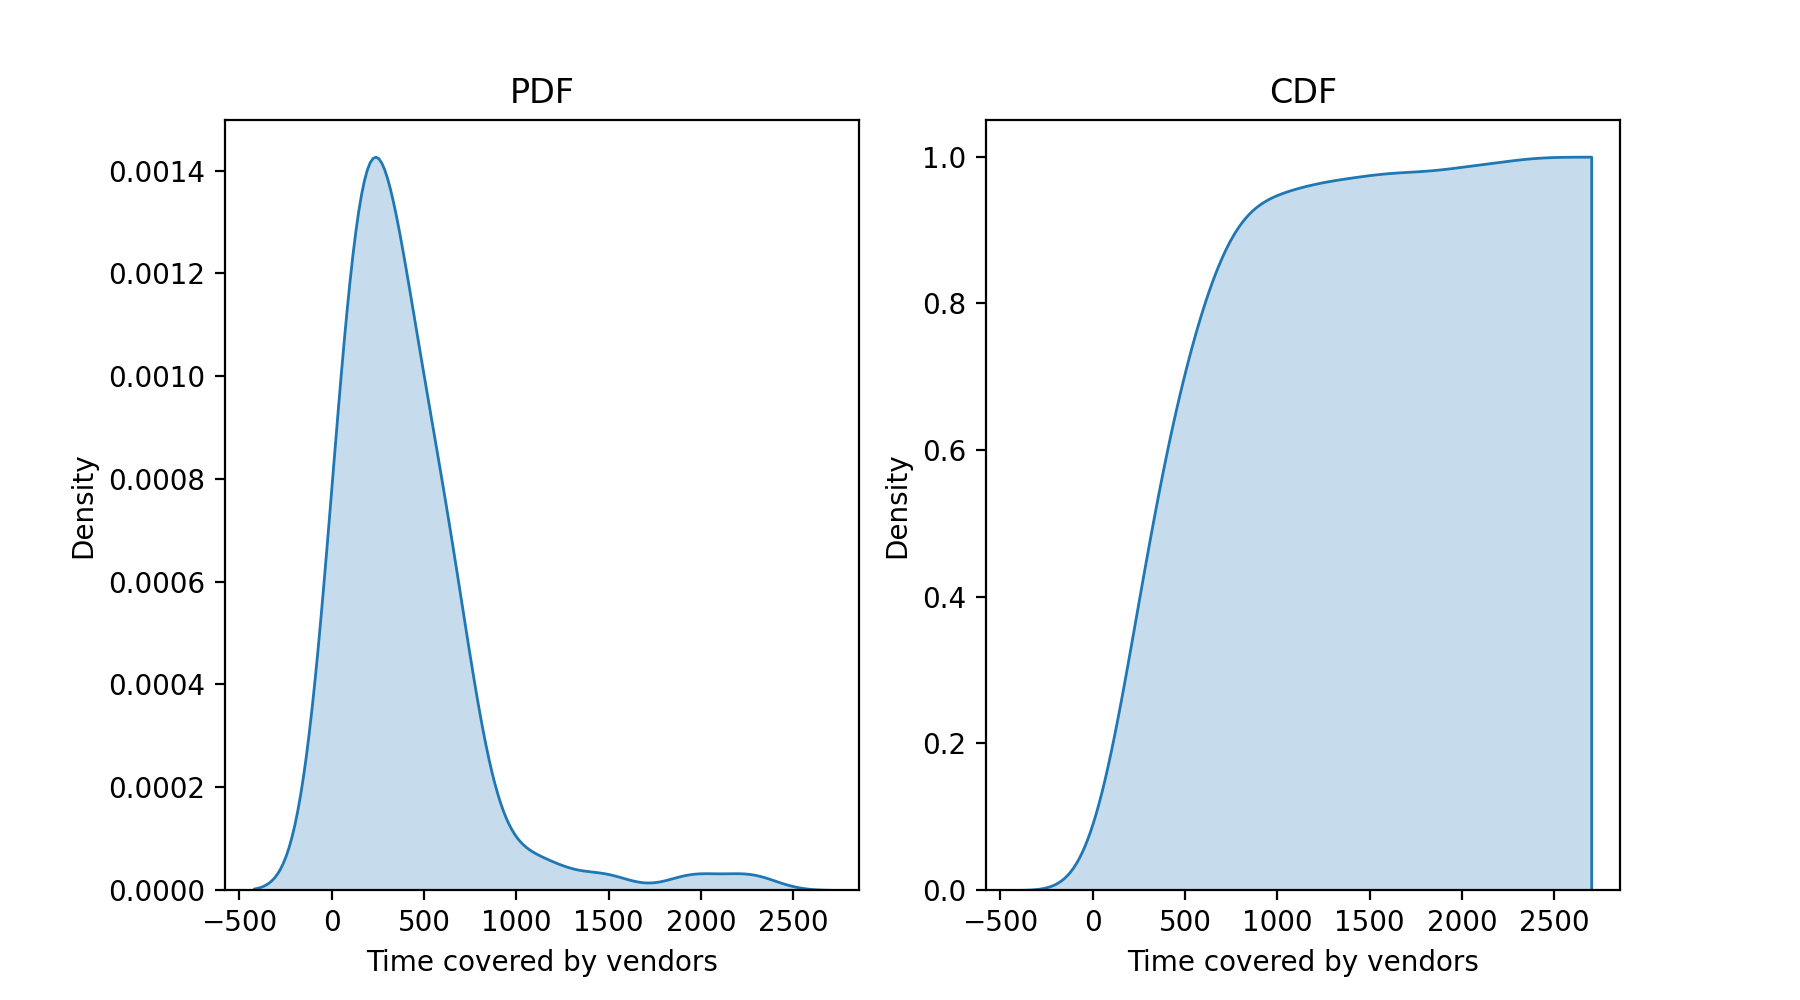

In [41]:
fig = plt.figure(figsize=(9,5))
ax1 = plt.subplot(121)
sns.kdeplot(dist, shade=True, ax=ax1)
plt.xlabel('Time covered by vendors')
plt.title("PDF")
ax2 = plt.subplot(122)
sns.kdeplot(dist, shade=True, cumulative=True,ax=ax2)
plt.xlabel('Time covered by vendors')
plt.title('CDF')
plt.show()